# Telco Customer Churn Prediction

Predicting customer churn for a telecom company using classical ML models.
Comparing logistic regression, random forest, and XGBoost.

**Dataset:** Telco Customer Churn (Kaggle, 7,043 customers, 21 features)
**Target:** `Churn` (Yes/No) — binary classification

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# Style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory data analysis

In [2]:
# Basic info about each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# TotalCharges is stored as text — convert to numeric
# Some rows have empty strings, which pd.to_numeric will turn into NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# How many missing values do we have now?
print(f"Missing TotalCharges: {df['TotalCharges'].isna().sum()}")

# These 11 rows are customers with tenure = 0 (brand new), so TotalCharges is empty
# We'll drop them since they're a tiny fraction and may not represent real churn behavior
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
print(f"Shape after cleaning: {df.shape}")

Missing TotalCharges: 11
Shape after cleaning: (7032, 21)


Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn rate: 26.58%


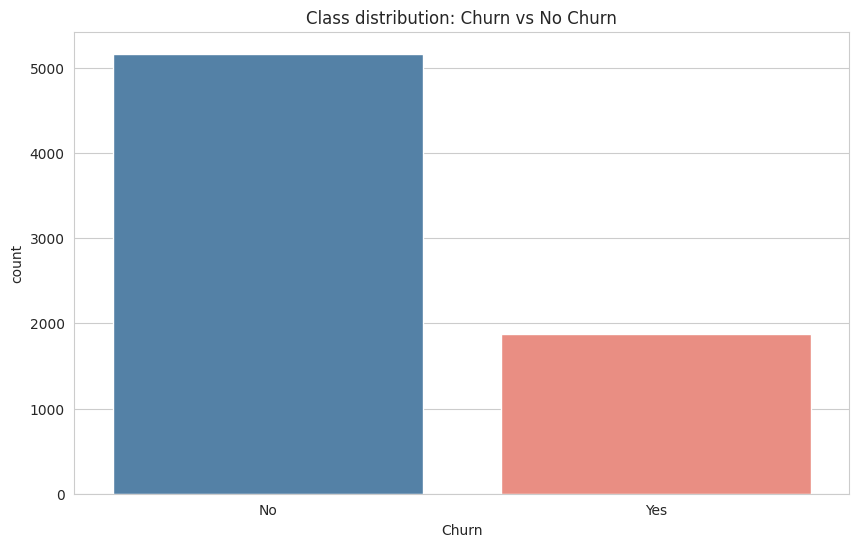

In [4]:
# What's the class balance?
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print(f"\nChurn rate: {churn_counts['Yes'] / len(df) * 100:.2f}%")

# Visualize it
sns.countplot(data=df, x="Churn", hue="Churn", palette=["steelblue", "salmon"], legend=False)
plt.title("Class distribution: Churn vs No Churn")
plt.show()

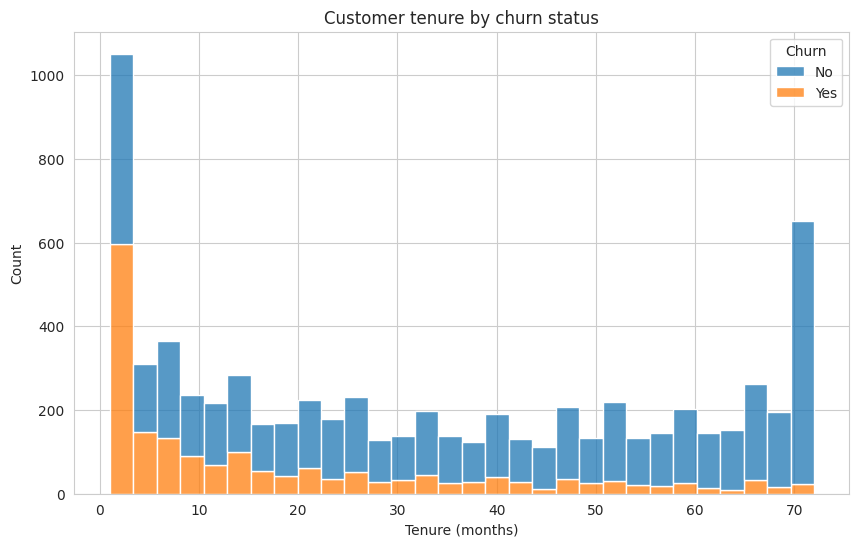

In [5]:
# How does tenure relate to churn?
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30)
plt.title("Customer tenure by churn status")
plt.xlabel("Tenure (months)")
plt.show()

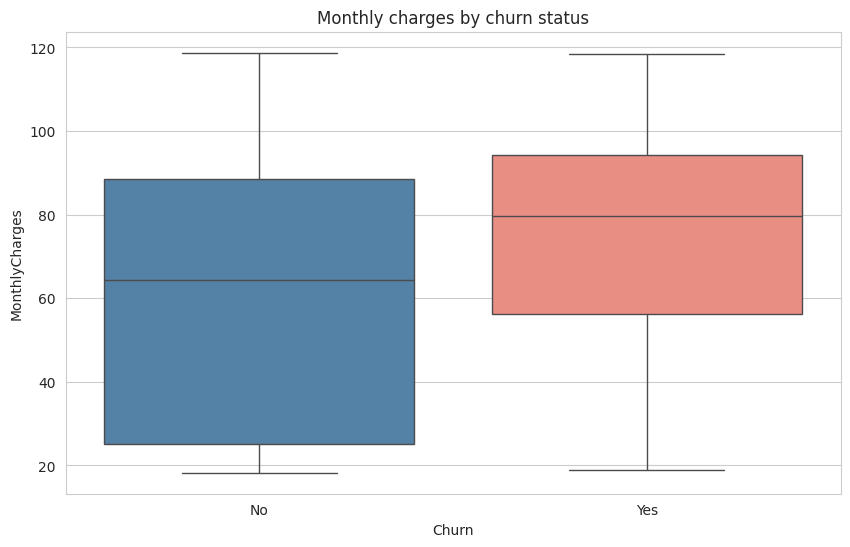

In [6]:
# Monthly charges vs churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", palette=["steelblue", "salmon"], legend=False)
plt.title("Monthly charges by churn status")
plt.show()

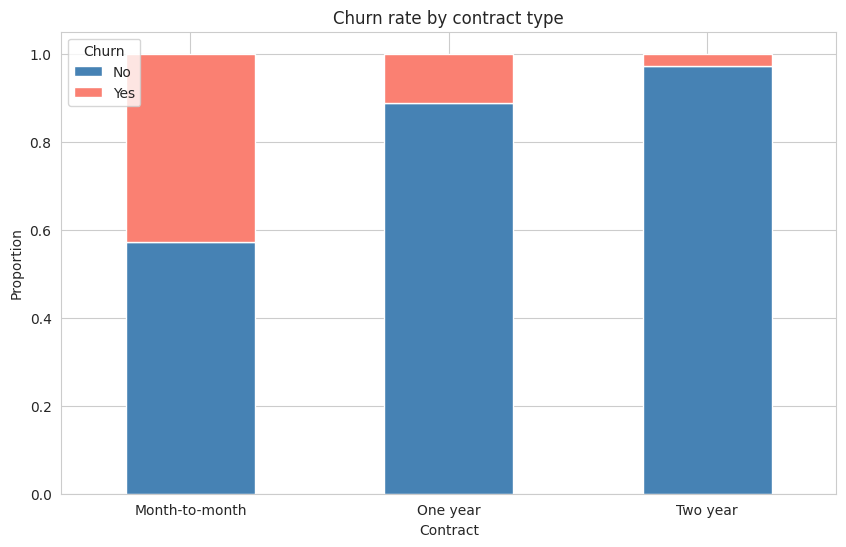

In [7]:
# Churn rate by contract type
contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()
contract_churn.plot(kind="bar", stacked=True, color=["steelblue", "salmon"], figsize=(10, 6))
plt.title("Churn rate by contract type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

## Preprocessing

In [8]:
# Drop customerID — it's just an identifier, no predictive value
df = df.drop(columns=["customerID"])

# Convert target to 0/1
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Identify numeric and categorical columns
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"Numeric features: {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [9]:
# 80/20 split, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")

Train: (5625, 19), Test: (1407, 19)
Train churn rate: 0.266
Test churn rate: 0.266


In [10]:
# A pipeline applies preprocessing consistently to train and test
# Numeric features get scaled, categorical features get one-hot encoded
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

## Model training and comparison

In [11]:
# Define the three models we want to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss")
}

# We'll use 5-fold cross-validation on the training set for a robust comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    # Build the full pipeline: preprocess then model
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # Cross-validate using ROC-AUC (good for imbalanced classification)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

    results[name] = scores
    print(f"{name}: ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: ROC-AUC = 0.8460 (+/- 0.0052)
Random Forest: ROC-AUC = 0.8299 (+/- 0.0075)
XGBoost: ROC-AUC = 0.8212 (+/- 0.0082)


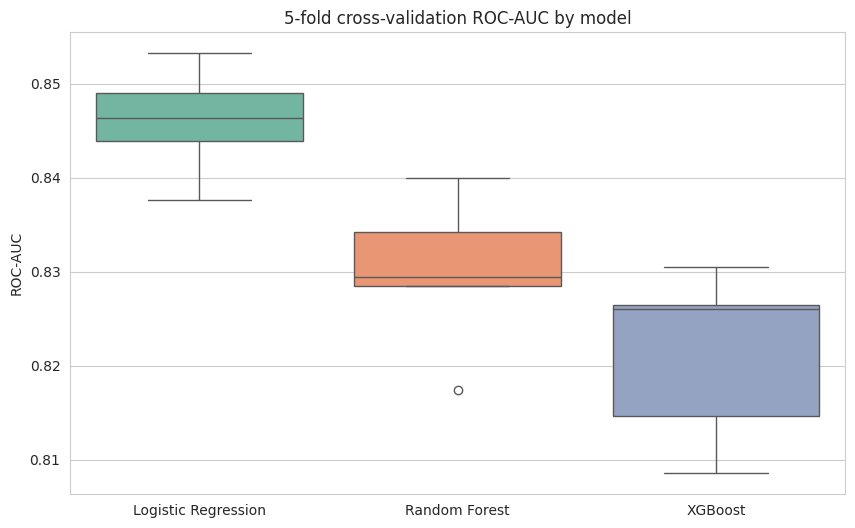


Mean scores:
Logistic Regression    0.846030
Random Forest          0.829875
XGBoost                0.821208
dtype: float64


In [12]:
# Compare CV scores in a box plot
results_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, palette="Set2")
plt.title("5-fold cross-validation ROC-AUC by model")
plt.ylabel("ROC-AUC")
plt.show()

print("\nMean scores:")
print(results_df.mean().sort_values(ascending=False))

## Final model evaluation

In [13]:
# Train the best model on full training set, evaluate on test set
best_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

print("Test set performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Test set performance:
Accuracy:  0.8045
Precision: 0.6505
Recall:    0.5722
F1 score:  0.6088
ROC-AUC:   0.8361

Classification report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



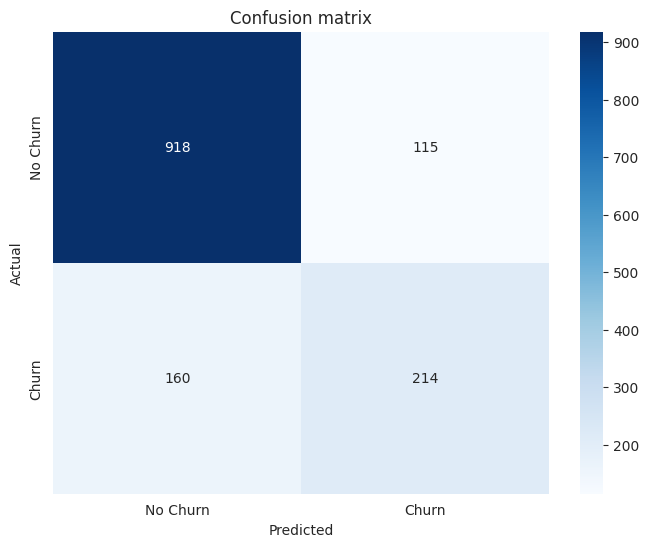

In [14]:
# Confusion matrix visualisation
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

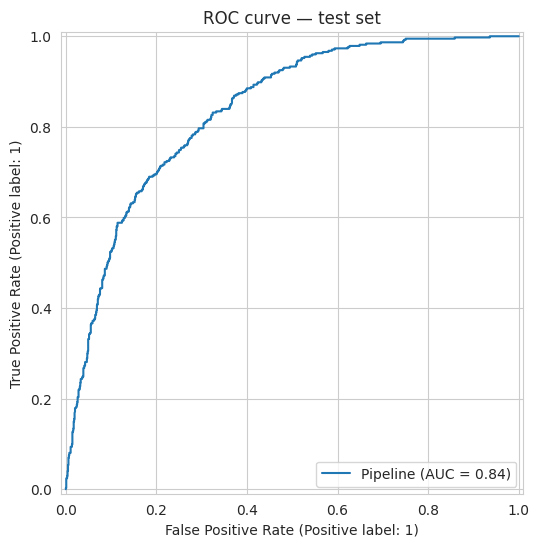

In [15]:
# ROC curve on test set
RocCurveDisplay.from_estimator(best_pipe, X_test, y_test)
plt.title("ROC curve — test set")
plt.show()

## What drives churn?

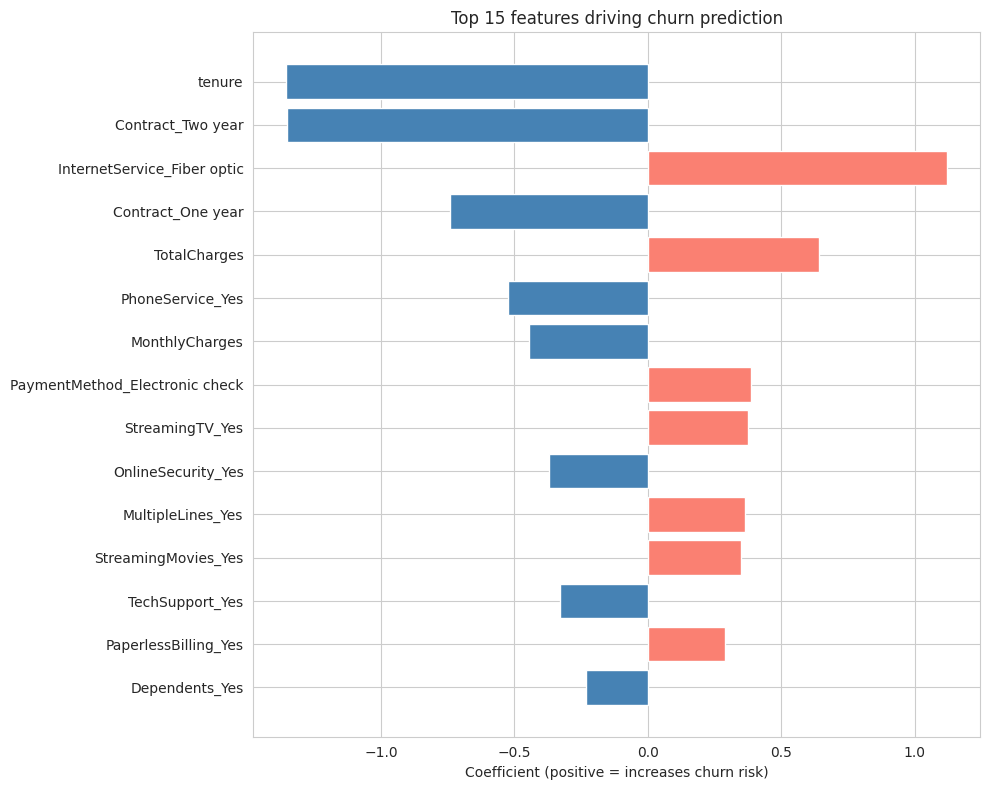

In [16]:
# Get feature names after one-hot encoding
ohe = best_pipe.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Logistic regression coefficients
# Positive coefficient = increases churn probability, negative = decreases it
coefs = best_pipe.named_steps["classifier"].coef_[0]
feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=False)

# Plot top 15 features by absolute coefficient size
top_15 = feature_importance.head(15)
plt.figure(figsize=(10, 8))
colors = ["salmon" if c > 0 else "steelblue" for c in top_15["coefficient"]]
plt.barh(top_15["feature"], top_15["coefficient"], color=colors)
plt.xlabel("Coefficient (positive = increases churn risk)")
plt.title("Top 15 features driving churn prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()